Tyler Fields

CSCI 4650

Homework 2

In [1]:
import numpy as np
from scipy.optimize import fsolve
import scipy.optimize
from math import sqrt
import matplotlib.pyplot as plt

In [2]:
# -----------------
# Exercise CP.1.1.2
# -----------------
# Use the Bisection Method to find the root to eight correct decimal places

# Bisection Method
# Computes an approximate solution of f(x)=0 using the bisection method
#
# Input:  f:        function: ( f: R -> R )
#         a and b:     float: numbers a and b such that f(a) * f(b) < 0
#         tol:         float: tolerance
#         verbose:   boolean: True=print, False = no print
#
# Output: c:           float: an approximate solution c of f(x)=0
#         err_bound:   float: bound on the error
#         numeval:       int: number of function evaluations
#
# Assumption: f is continuous on [a,b]

def bisect( f, a, b, tol, verbose ):

  numeval = 0

  err_bound = []

  k = 0

  fa = f(a)
  numeval += 1

  if ( fa == 0 ): # `a` is a solution, done
    if ( verbose ): print( 'f(a) = 0, returning `a` as a solution ' )
    return a, 0., numeval

  fb = f(b)
  numeval += 1

  if ( fb == 0 ): # `b` is a solution, done
    if ( verbose ): print( 'f(b) = 0, returning `b` as a solution ' )
    return b, 0., numeval

  if ( ( fa > 0 ) and ( fb > 0 ) ) or ( ( fa < 0 ) and ( fb < 0 ) ):
    print( '[ error ] f(a) and f(b) have the same sign' )
    return float("NaN"), numeval, float("NaN")

  if ( ( b - a ) / 2 <=  tol ):
    c = ( a + b ) / 2
    err_bound.append( ( b - a ) / 2 )
    if ( verbose ): print( '( b - a ) / 2 <=  tol, f(a) and f(b) opposite signs' )
    if ( verbose ): print( 'returning c = ( b + a ) / 2 as an approximate solution' )
    return c, numeval, err_bound

  while ( ( b - a ) / 2 > tol ):

    c = ( a + b ) / 2

    err_bound.append( ( b - a ) / 2 )

    if ( verbose ): print( f"{k:3d}", f"{c:20.16f}", '  ', f"{err_bound[k]:3.1e}" )

    k = k + 1

    fc = f(c)
    numeval += 1

    if ( fc == 0 ): # `c` is a solution, done
      return c, 0., numeval

    if ( ( fb > 0 ) and ( fc > 0 ) ) or ( ( fb < 0 ) and ( fc < 0 ) ):
#     `a` and `c` make the new interval
#     so replace `b` with `c`
      b = c
      fb = fc

    else:
#     `c` and `b` make the new interval
#     so replace `a` with `c`
      a = c
      fa = fc

    c = ( a + b ) / 2

  err_bound.append( (b - a ) / 2 )

  if ( verbose ): print( f"{k:3d}", f"{c:20.16f}", '  ', f"{err_bound[k]:3.1e}" )

  return c, err_bound, numeval

In [3]:
# (a) x^5 + x = 1

f = lambda x: x**5 + x - 1.

x_fsolve = scipy.optimize.fsolve(f, 1.)[0]
print(x_fsolve)

r = np.roots([1., 0., 0., 0., 1., -1.])
x_roots = np.real(r[np.isreal(r)])[0]
print(x_roots)

x_bisec, err_bound, numeval = bisect(f, 0., 1., 1e-8, False)
print(x_bisec, err_bound[-1], numeval)

0.7548776662466931
0.7548776662466931
0.7548776641488075 7.450580596923828e-09 28


In [4]:
# (b) sin(x) = 6x + 5

f = lambda x: np.sin(x) - 6*x - 5.

x_fsolve = scipy.optimize.fsolve(f, -1.)[0]
print(x_fsolve)

x_bisec, err_bound, numeval = bisect(f, -1., 0., 1e-8, False)
print(x_bisec, err_bound[-1], numeval)

-0.9708989235042559
-0.9708989188075066 7.450580596923828e-09 28


In [ ]:
# (c) ln(x) + x^2 = 3

f = lambda x: np.log(x) + x**2 - 3.

x_fsolve = scipy.optimize.fsolve(f, 1.)[0]
print(x_fsolve)

x_bisec, err_bound, numeval = bisect(f, 1., 2., 1e-8, False)
print(x_bisec, err_bound[-1], numeval)

1.592142937058094
1.5921429321169853 7.450580596923828e-09 28


In [ ]:
# -----------------
# Exercise CP.1.2.4
# -----------------
# (a) 2

A = 2.

r = sqrt( A )

x = 1.3
true_fwd_rel_error = abs( r - x ) / abs( r )
print( f"{0:2d}", f"{x:.15f}", f"{true_fwd_rel_error:.2e}" )

for i in range(0,10):
  x = ( 2*x + A / x**2 ) / 3.
  true_fwd_rel_error = abs( r - x ) / abs( r )
  print( f"{i+1:2d}", f"{x:.15f}", f"{true_fwd_rel_error:.2e}" )

# I chose x = 1.3 as the initial guess
# 4 iterations are needed to obtain an answer correct to 8 decimal places

 0 1.300000000000000 8.08e-02
 1 1.261143984220907 1.08e-01
 2 1.259922235393885 1.09e-01
 3 1.259921049895989 1.09e-01
 4 1.259921049894873 1.09e-01
 5 1.259921049894873 1.09e-01
 6 1.259921049894873 1.09e-01
 7 1.259921049894873 1.09e-01
 8 1.259921049894873 1.09e-01
 9 1.259921049894873 1.09e-01
10 1.259921049894873 1.09e-01


In [ ]:
# (b) 3

A = 3.

r = sqrt( A )

x = 1.4
true_fwd_rel_error = abs( r - x ) / abs( r )
print( f"{0:2d}", f"{x:.15f}", f"{true_fwd_rel_error:.2e}" )

for i in range(0,10):
  x = ( 2*x + A / x**2 ) / 3.
  true_fwd_rel_error = abs( r - x ) / abs( r )
  print( f"{i+1:2d}", f"{x:.15f}", f"{true_fwd_rel_error:.2e}" )

# I chose x = 1.4 as the initial guess
# 4 iterations are needed to obtain an answer correct to 8 decimal places

 0 1.400000000000000 1.92e-01
 1 1.443537414965986 1.67e-01
 2 1.442250718909881 1.67e-01
 3 1.442249570308323 1.67e-01
 4 1.442249570307409 1.67e-01
 5 1.442249570307409 1.67e-01
 6 1.442249570307409 1.67e-01
 7 1.442249570307409 1.67e-01
 8 1.442249570307409 1.67e-01
 9 1.442249570307409 1.67e-01
10 1.442249570307409 1.67e-01


In [ ]:
# (c) 5

A = 5

r = sqrt( A )

x = 2
true_fwd_rel_error = abs( r - x ) / abs( r )
print( f"{0:2d}", f"{x:.15f}", f"{true_fwd_rel_error:.2e}" )

for i in range(0,10):
  x = ( 2*x + A / x**2 ) / 3.
  true_fwd_rel_error = abs( r - x ) / abs( r )
  print( f"{i+1:2d}", f"{x:.15f}", f"{true_fwd_rel_error:.2e}" )

# I chose x = 2 as the initial guess
# 5 iterations are needed to obtain an answer correct to 8 decimal places

 0 2.000000000000000 1.06e-01
 1 1.750000000000000 2.17e-01
 2 1.710884353741497 2.35e-01
 3 1.709976428916975 2.35e-01
 4 1.709975946676833 2.35e-01
 5 1.709975946676697 2.35e-01
 6 1.709975946676697 2.35e-01
 7 1.709975946676697 2.35e-01
 8 1.709975946676697 2.35e-01
 9 1.709975946676697 2.35e-01
10 1.709975946676697 2.35e-01


In [ ]:
# -----------------
# Exercise CP.1.3.2
# -----------------

root = fsolve(lambda x: np.sin(x**3) - x**3, 0.1)

r_computed = root[0]
forward_error = abs(0 - r_computed)
backward_error = abs(np.sin(r_computed**3) - r_computed**3)

print("root =", r_computed)
print("Forward error  =", forward_error)
print("Backward error =", backward_error)

root = 0.003093005095916197
Forward error  = 0.003093005095916197
Backward error = 3.308722450212111e-24


/tmp/ipykernel_9680/2177400935.py:5: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  root = fsolve(lambda x: np.sin(x**3) - x**3, 0.1)


In [ ]:
# -----------------
# Exercise CP.1.4.2
# -----------------
# (a) x^5 + x = 1

f = lambda x : ( x ** 5 ) + x - 1.

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

p = np.roots( [ 1., 0., 0., 0., 1., -1.] )
x_roots = np.real(p[np.isreal(p)])[0]
print( "  ", f"{x_roots:.16f}" )

dfdx = lambda x : 5 * ( x ** 4 ) + 1.

r = x_fsolve

x = 1.
for i in range(0,8):
  x = x - f(x) / dfdx(x)
  true_fwd_rel_error = abs( r - x ) / abs( r )
  print( f"{i+1:2d}", f"{x:.16f}", f"{true_fwd_rel_error:.2e}" )

   0.7548776662466931
   0.7548776662466931
 1 0.8333333333333334 1.04e-01
 2 0.7643821156601071 1.26e-02
 3 0.7550248672318378 1.95e-04
 4 0.7548777017701278 4.71e-08
 5 0.7548776662466948 2.35e-15
 6 0.7548776662466928 2.94e-16
 7 0.7548776662466927 4.41e-16
 8 0.7548776662466927 4.41e-16


In [ ]:
# (b) sinx = 6x + 5

f = lambda x : np.sin(x) - 6 * x - 5.

x_fsolve = scipy.optimize.fsolve( f, -1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

dfdx = lambda x : np.cos(x) - 6.

r = x_fsolve

x = -1.
for i in range(0,8):
  x = x - f(x) / dfdx(x)
  true_fwd_rel_error = abs( r - x ) / abs( r )
  print( f"{i+1:2d}", f"{x:.16f}", f"{true_fwd_rel_error:.2e}" )

   -0.9708989235042559
 1 -0.9709637741733408 6.68e-05
 2 -0.9708989238235813 3.29e-10
 3 -0.9708989235042558 1.14e-16
 4 -0.9708989235042558 1.14e-16
 5 -0.9708989235042558 1.14e-16
 6 -0.9708989235042558 1.14e-16
 7 -0.9708989235042558 1.14e-16
 8 -0.9708989235042558 1.14e-16


In [ ]:
# (c) lnx + x^2 = 3

f = lambda x : np.log(x) + x ** 2 - 3.

x_fsolve = scipy.optimize.fsolve( f, 1.5 )[0]
print( "  ", f"{x_fsolve:.16f}" )

dfdx = lambda x : 1. / x + 2 * x

r = x_fsolve

x = 1.5
for i in range(0,8):
  x = x - f(x) / dfdx(x)
  true_fwd_rel_error = abs( r - x ) / abs( r )
  print( f"{i+1:2d}", f"{x:.16f}", f"{true_fwd_rel_error:.2e}" )

   1.5921429370580940
 1 1.5939640614250461 1.14e-03
 2 1.5921436351243661 4.38e-07
 3 1.5921429370581965 6.44e-14
 4 1.5921429370580940 0.00e+00
 5 1.5921429370580937 1.39e-16
 6 1.5921429370580940 0.00e+00
 7 1.5921429370580937 1.39e-16
 8 1.5921429370580940 0.00e+00


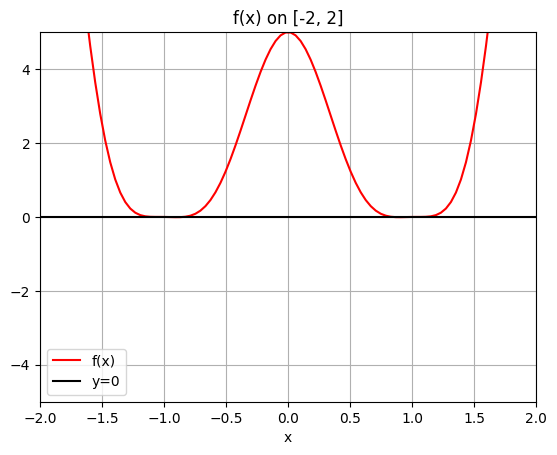

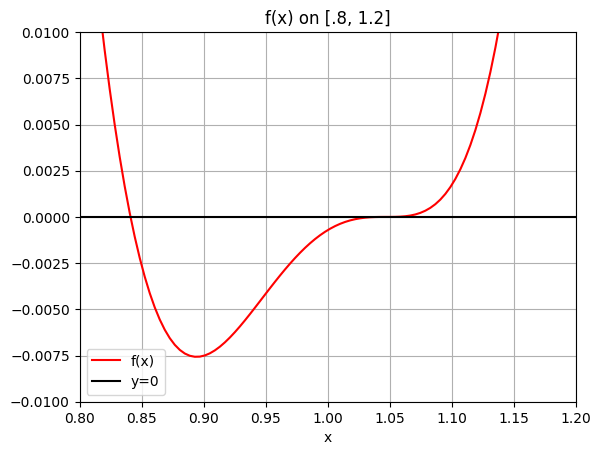

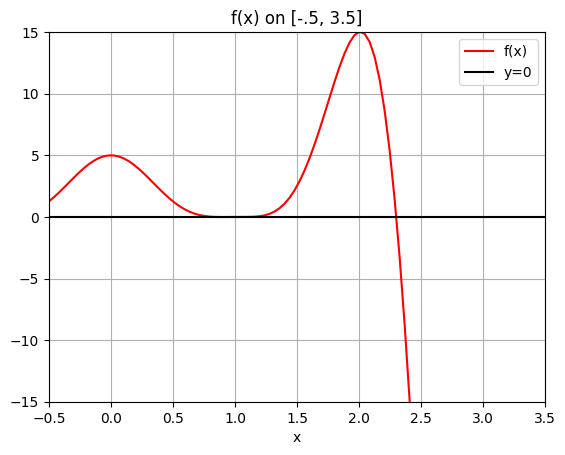


root near x0=0.8:   0.8410686705679508   bwd_error= 2.84e-14
 0 0.8000000000000000 4.88e-02
 1 0.8282912235570670 1.52e-02
 2 0.8392915319171710 2.11e-03
 3 0.8410273379554311 4.91e-05
 4 0.8410686474746497 2.75e-08
 5 0.8410686705679322 2.20e-14
 6 0.8410686705679751 2.89e-14
 7 0.8410686705679322 2.20e-14
Value of derivative at root: -3.3127e-01
The value of the derivative at r= 0.8410686705679508  is  -3.31e-01
the value of the derivative at r is large therefore we have locally quadratic convergence with Newton

root near x0=1.0:   1.0471919017415898   bwd_error= 0.00e+00
 0 1.0000000000000000 4.51e-02
 1 1.0176444552445429 2.82e-02
 2 1.0281375443989444 1.82e-02
 3 1.0347368039727372 1.19e-02
 4 1.0389904857202676 7.83e-03
 5 1.0417682978201837 5.18e-03
 6 1.0435961291789357 3.43e-03
 7 1.0448044593152328 2.28e-03
Value of derivative at root: 8.7061e-10
The value of the derivative at r= 1.0471919017415898  is  8.71e-10
The value of the derivative at r is approximately zero therefo

In [ ]:
# -----------------
# Exercise CP.1.4.8
# -----------------

f = lambda x : 94. * ( ( np.cos( x ) ) ** 3 ) \
               - 24. * ( np.cos( x ) ) \
               + 177. * ( ( np.sin( x ) ) ** 2 ) \
               - 108. * ( ( np.sin( x ) ) ** 4 ) \
               - 72. * ( ( np.cos( x ) ) ** 3 ) * ( ( np.sin( x ) ) ** 2 ) \
               - 65.

xx = np.linspace(-2, 2, 100)
yy = f(xx)
plt.plot(xx, yy, '-r', label='f(x)')
xx2 = np.linspace(-2, 2, 10)
yy2 = np.zeros([10])
plt.plot(xx2, yy2, '-k', label='y=0')
plt.title('f(x) on [-2, 2]')
plt.xlabel('x')
plt.legend()
plt.xlim([-2., 2.])
plt.ylim([-5, 5])
plt.grid()
plt.show()

xx = np.linspace(.8, 1.2, 100)
yy = f(xx)
plt.plot(xx, yy, '-r', label='f(x)')
xx2 = np.linspace(.8, 1.2, 10)
yy2 = np.zeros([10])
plt.plot(xx2, yy2, '-k', label='y=0')
plt.title('f(x) on [.8, 1.2]')
plt.xlabel('x')
plt.legend()
plt.xlim([.8, 1.2])
plt.ylim([-.01, .01])
plt.grid()
plt.show()

xx = np.linspace(-.5, 3.5, 100)
yy = f(xx)
plt.plot(xx, yy, '-r', label='f(x)')
xx2 = np.linspace(-.5, 3.5, 10)
yy2 = np.zeros([10])
plt.plot(xx2, yy2, '-k', label='y=0')
plt.title('f(x) on [-.5, 3.5]')
plt.xlabel('x')
plt.legend()
plt.xlim([-.5, 3.5])
plt.ylim([-15, 15])
plt.grid()
plt.show()


dfdx = lambda x : 216. * ( ( np.sin( x ) ) ** 3 ) * ( ( np.cos( x ) ) ** 2 ) \
                 - 432. * ( ( np.sin( x ) ) ** 3 ) * ( np.cos( x ) ) \
                 - 144. * ( np.sin( x ) ) * ( ( np.cos( x ) ) ** 4 ) \
                 - 282. * ( np.sin( x ) ) * ( ( np.cos( x ) ) ** 2 ) \
                 + 354. * ( np.sin( x ) ) * ( np.cos( x ) ) \
                 + 24. * ( np.sin( x ) )

# three different initial guesses, one per root
initial_guesses = [0.8, 1.0, 2.3]

for x0 in initial_guesses:
    x_fsolve = scipy.optimize.fsolve( f, x0 )[0]
    bwd_error = abs(f(x_fsolve))
    print( f"\nroot near x0={x0}:  ", f"{x_fsolve:.16f}", "  bwd_error=", f"{bwd_error:.2e}" )

    r = x_fsolve
    x = x0
    fwd_rel_error = abs( r - x ) / abs( r )
    print( f"{0:2d}", f"{x:.16f}", f"{fwd_rel_error:.2e}" )
    for i in range(1,8):
        x = x - f(x) / dfdx(x)
        fwd_rel_error = abs( r - x ) / abs( r )
        print( f"{i:2d}", f"{x:.16f}", f"{fwd_rel_error:.2e}" )

    print( "Value of derivative at root:", f"{dfdx(r):.4e}" )

    deriv_at_root = dfdx(r)
    print( "The value of the derivative at r=", r, " is ", f"{deriv_at_root:.2e}" )
    if abs(deriv_at_root) > 1e-6:
        print( "the value of the derivative at r is large therefore we have locally quadratic convergence with Newton" )
    else:
        print( "The value of the derivative at r is approximately zero therefore Newton does NOT converge quadratically. Convergence is linear, r is a root of multiplicity greater than 1" )


In [ ]:
# -----------------
# Exercise CP.1.5.1
# -----------------
# (a) x^3 = 2x + 2

def secant_method( f, x0, x1, numiter, r ):

  true_fwd_rel_error = abs( r - x0 ) / abs( r )
  print( f"{0:2d}", f"{x0:.16f}", f"{true_fwd_rel_error:.2e}" )

  true_fwd_rel_error = abs( r - x1 ) / abs( r )
  print( f"{1:2d}", f"{x1:.16f}", f"{true_fwd_rel_error:.2e}" )

  fx0 = f( x0 )
  for i in range(1,numiter):
    fx1 = f( x1 )
    x = x1 - fx1 * ( x1 - x0 ) / ( fx1 - fx0 )
    true_fwd_rel_error = abs( r - x ) / abs( r )
    print( f"{i+1:2d}", f"{x:.16f}", f"{true_fwd_rel_error:.2e}" )
    x0 = x1
    fx0 = fx1
    x1 = x
  return x

f = lambda x : ( x ** 3 ) - ( 2 * x ) - 2

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

r = np.roots( [ 1., 0., -2., -2.] )
x_roots = np.real(r[np.isreal(r)])[0]
print( "  ", f"{x_roots:.16f}" )


x0 = 1
x1 = 2

x = secant_method( f, x0, x1, 8, x_fsolve )

   1.7692923542386312
   1.7692923542386312
 0 1.0000000000000000 4.35e-01
 1 2.0000000000000000 1.30e-01
 2 1.6000000000000001 9.57e-02
 3 1.7422680412371134 1.53e-02
 4 1.7729559878279366 2.07e-03
 5 1.7692203651195755 4.07e-05
 6 1.7692921651959501 1.07e-07
 7 1.7692923542484049 5.52e-12
 8 1.7692923542386314 1.25e-16


In [ ]:
# (b) e^x + x = 7
f = lambda x : np.exp(x) + x - 7

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

x0 = 1
x1 = 2

x = secant_method( f, x0, x1, 8, x_fsolve )

   1.6728216986289064
 0 1.0000000000000000 4.02e-01
 1 2.0000000000000000 1.96e-01
 2 1.5787072479025044 5.63e-02
 3 1.6601600999426993 7.57e-03
 4 1.6733279622124804 3.03e-04
 5 1.6728189972632956 1.61e-06
 6 1.6728216980532040 3.44e-10
 7 1.6728216986289073 5.31e-16
 8 1.6728216986289064 0.00e+00


In [ ]:
# (c) e^x + sin(x) = 4
f = lambda x : np.exp(x) + np.sin(x) - 4

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

x0 = 1
x1 = 2

x = secant_method( f, x0, x1, 8, x_fsolve )

   1.1299804986508324
 0 1.0000000000000000 1.15e-01
 1 2.0000000000000000 7.70e-01
 2 1.0929065801160904 3.28e-02
 3 1.1193566855644101 9.40e-03
 4 1.1301024531032799 1.08e-04
 5 1.1299800960524500 3.56e-07
 6 1.1299804986355602 1.35e-11
 7 1.1299804986508324 0.00e+00
 8 1.1299804986508324 0.00e+00


In [ ]:
# -----------------
# Exercise CP.1.5.2
# -----------------
# (a) x^3 = 2x + 2

def method_of_false_position( f, a, b, numiter, r ):

  fa = f(a)
  fb = f(b)

  for i in range(0,numiter):
    c = ( b*f(a) - a*fb ) / ( fa - fb )
    true_fwd_rel_error = abs( r - c ) / abs( r )
    print( f"{i+1:2d}", f"{c:.16f}", f"{true_fwd_rel_error:.2e}" )
    fc = f(c)
    if ( ( fb > 0 ) and ( fc > 0 ) ) or ( ( fb < 0 ) and ( fc < 0 ) ):
      b = c
      fb = fc
    else:
      a = c
      fa = fc

  return c

f = lambda x : ( x ** 3 ) - ( 2 * x ) - 2

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

r = np.roots( [ 1., 0., -2., -2.] )
x_roots = np.real(r[np.isreal(r)])[0]
print( "  ", f"{x_roots:.16f}" )

a = 1
b = 2

x = method_of_false_position( f, a, b, 19, x_fsolve )

   1.7692923542386312
   1.7692923542386312
 1 1.6000000000000001 9.57e-02
 2 1.7422680412371134 1.53e-02
 3 1.7652591529969437 2.28e-03
 4 1.7686967661242612 3.37e-04
 5 1.7692045415304856 4.96e-05
 6 1.7692794102646114 7.32e-06
 7 1.7692904463061978 1.08e-06
 8 1.7692920730121895 1.59e-07
 9 1.7692923127862974 2.34e-08
10 1.7692923481286233 3.45e-09
11 1.7692923533380260 5.09e-10
12 1.7692923541058836 7.50e-11
13 1.7692923542190646 1.11e-11
14 1.7692923542357473 1.63e-12
15 1.7692923542382064 2.40e-13
16 1.7692923542385688 3.53e-14
17 1.7692923542386221 5.15e-15
18 1.7692923542386301 6.27e-16
19 1.7692923542386312 0.00e+00


In [ ]:
# (b) e^x + x = 7

f = lambda x : np.exp(x) + x - 7

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

a = 1
b = 2

x = method_of_false_position( f, a, b, 19, x_fsolve )

   1.6728216986289064
 1 1.5787072479025042 5.63e-02
 2 1.6601600999426993 7.57e-03
 3 1.6711295739211935 1.01e-03
 4 1.6725957667131959 1.35e-04
 5 1.6727915359888301 1.80e-05
 6 1.6728176718852903 2.41e-06
 7 1.6728211610556529 3.21e-07
 8 1.6728216268625002 4.29e-08
 9 1.6728216890480414 5.73e-09
10 1.6728216973498544 7.65e-10
11 1.6728216984581523 1.02e-10
12 1.6728216986061106 1.36e-11
13 1.6728216986258633 1.82e-12
14 1.6728216986285003 2.43e-13
15 1.6728216986288524 3.23e-14
16 1.6728216986288993 4.25e-15
17 1.6728216986289055 5.31e-16
18 1.6728216986289064 0.00e+00
19 1.6728216986289064 0.00e+00


In [ ]:
# (c) e^x + sin(x) = 4

f = lambda x : np.exp(x) + np.sin(x) - 4

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "  ", f"{x_fsolve:.16f}" )

a = 1
b = 2

x = method_of_false_position( f, a, b, 19, x_fsolve )

   1.1299804986508324
 1 1.0929065801160904 3.28e-02
 2 1.1193566855644101 9.40e-03
 3 1.1269323018857849 2.70e-03
 4 1.1291055934589549 7.74e-04
 5 1.1297293543183931 2.22e-04
 6 1.1299084047549419 6.38e-05
 7 1.1299598030871578 1.83e-05
 8 1.1299745576847615 5.26e-06
 9 1.1299787932079237 1.51e-06
10 1.1299800090779146 4.33e-07
11 1.1299803581115893 1.24e-07
12 1.1299804583069357 3.57e-08
13 1.1299804870695120 1.02e-08
14 1.1299804953262407 2.94e-09
15 1.1299804976964587 8.45e-10
16 1.1299804983768651 2.42e-10
17 1.1299804985721860 6.96e-11
18 1.1299804986282558 2.00e-11
19 1.1299804986443516 5.74e-12


In [ ]:
# -----------------
# Exercise CP.1.5.3
# -----------------
# (a) x^3 = 2x + 2

def inverse_quadratic_interpolation( f, a, b, c, numiter, rr ):

  fa = f(a)
  fb = f(b)

  for i in range(0,numiter):

    fc = f(c)

    q = fa / fb
    r = fc / fb
    s = fc / fa

    x = c - ( r * ( r - q ) * ( c - b ) + ( 1 - r ) * s * ( c - a ) ) \
          / ( ( q - 1. ) * ( r - 1. ) * ( s - 1. ) )

    true_fwd_rel_error = abs( rr - x ) / abs( rr )

    print( f"{i+1:2d}", f"{x:20.16f}", f"{true_fwd_rel_error:.2e}" )

    a = b
    fa = fb
    b = c
    fb = fc
    c = x

  return c

f = lambda x : ( x ** 3 ) - ( 2 * x ) - 2

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "    ", f"{x_fsolve:.16f}" )

r = np.roots( [ 1., 0., -2., -2.] )
x_roots = np.real(r[np.isreal(r)])[0]
print( "    ", f"{x_roots:.16f}" )

a = 1.
b = 2.
c = 0.

x = inverse_quadratic_interpolation( f, a, b, c, 30, x_fsolve )


     1.7692923542386312
     1.7692923542386312
 1  -0.1999999999999999 1.11e+00
 2  -0.1199601791936286 1.07e+00
 3  -1.1580007692962857 1.65e+00
 4 -12.1572812689860648 7.87e+00
 5  -3.6060885264071736 3.04e+00
 6  -1.0815185380159669 1.61e+00
 7  -1.0114756479243805 1.57e+00
 8  -0.2054604336859334 1.12e+00
 9   4.6173853301665471 1.61e+00
10  -2.3773358058814331 2.34e+00
11   0.1443423726971904 9.18e-01
12   0.7684099325505713 5.66e-01
13  -2.6488004643753440 2.50e+00
14  -2.2203900137243293 2.25e+00
15   3.5162429881210411 9.87e-01
16  -1.4989195775596222 1.85e+00
17  -1.2115191418246734 1.68e+00
18  -0.8408532975333224 1.48e+00
19   0.3948053928968701 7.77e-01
20   1.2922600455490416 2.70e-01
21  -7.4781168764359132 5.23e+00
22   8.5626911950999443 3.84e+00
23   1.3355149284442147 2.45e-01
24   1.3763933267903865 2.22e-01
25   1.9843023938814492 1.22e-01
26   1.8296484574881002 3.41e-02
27   1.7641930239436967 2.88e-03
28   1.7692440805120235 2.73e-05
29   1.7692923669817904 7.20

In [ ]:
# (b) e^x + x = 7

fa = lambda x : np.exp(x) + x - 7

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "    ", f"{x_fsolve:.16f}" )

a = 1.
b = 2.
c = 0.

x = inverse_quadratic_interpolation( fa, a, b, c, 8, x_fsolve )

     1.7692923542386312
 1   1.7577127926115119 6.54e-03
 2   1.6625311681869313 6.03e-02
 3   1.6731557444670717 5.43e-02
 4   1.6728216366556681 5.45e-02
 5   1.6728216986289521 5.45e-02
 6   1.6728216986289066 5.45e-02
 7   1.6728216986289064 5.45e-02
 8   1.6728216986289064 5.45e-02


In [ ]:
# (c) e^x + sin(x) = 4

f = lambda x : np.exp(x) + np.sin(x) - 4

x_fsolve = scipy.optimize.fsolve( f, 1. )[0]
print( "    ", f"{x_fsolve:.16f}" )

a = 1.
b = 2.
c = 0.

xb = inverse_quadratic_interpolation( f, a, b, c, 6, x_fsolve )

     1.1299804986508324
 1   1.1394815512864609 8.41e-03
 2   1.1292724601823607 6.27e-04
 3   1.1299809868365196 4.32e-07
 4   1.1299804986506110 1.96e-13
 5   1.1299804986508324 0.00e+00
 6   1.1299804986508324 0.00e+00
